# Week 3 - Assignment 1
## Exploratory Data Analysis (EDA) and Machine Learning on Agricultural Yield Dataset

**Name:** Prisha  
**Enrollment Number:** 15101012025  
**College:** IGDTUW  
**Internship:** Machine Learning and Generative AI using Python


### Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")
%matplotlib inline


## Part A: Understanding the Dataset

### Q1. Dataset Overview

In [2]:
df = pd.read_csv("agriculture_yield_dataset.csv")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(list(df.columns))


Number of rows: 1500
Number of columns: 8

Column names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


In [3]:
# Display first 10 records
df.head(10)


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


### Q2. Data Types and Missing Values

In [4]:
print("Data type of each column:\n")
print(df.dtypes)


Data type of each column:

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object


In [5]:
missing_values = df.isnull().sum()
print("Missing values in each column:\n")
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values are present in the dataset.")
else:
    affected = missing_values[missing_values > 0]
    print("\nColumns with missing values:")
    print(affected)


Missing values in each column:

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

No missing values are present in the dataset.


**Observation:** The dataset has no missing values in any column (as shown by the output above). 
All columns have complete data, so no imputation or row removal is required.

### Q3. Descriptive Statistics

In [6]:
desc = df.describe()
desc


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [7]:
numeric_df = df.select_dtypes(include=[np.number])

highest_mean_feature = numeric_df.mean().idxmax()
highest_mean_value = numeric_df.mean().max()

highest_std_feature = numeric_df.std().idxmax()
highest_std_value = numeric_df.std().max()

print(f"Feature with highest mean value      : {highest_mean_feature} ({highest_mean_value:.2f})")
print(f"Feature with highest standard deviation: {highest_std_feature} ({highest_std_value:.2f})")


Feature with highest mean value      : rainfall_mm (754.05)
Feature with highest standard deviation: rainfall_mm (255.10)


**Observations:**
- The feature with the **highest mean value** is identified above (typically `rainfall_mm`, since rainfall is measured in millimeters and naturally takes large numeric values compared to other features).
- The feature with the **highest standard deviation** is also identified above — this indicates which feature has the widest spread/variability across records.

## Part B: Exploratory Data Analysis (EDA)

### Q4. Distribution Analysis - Histograms

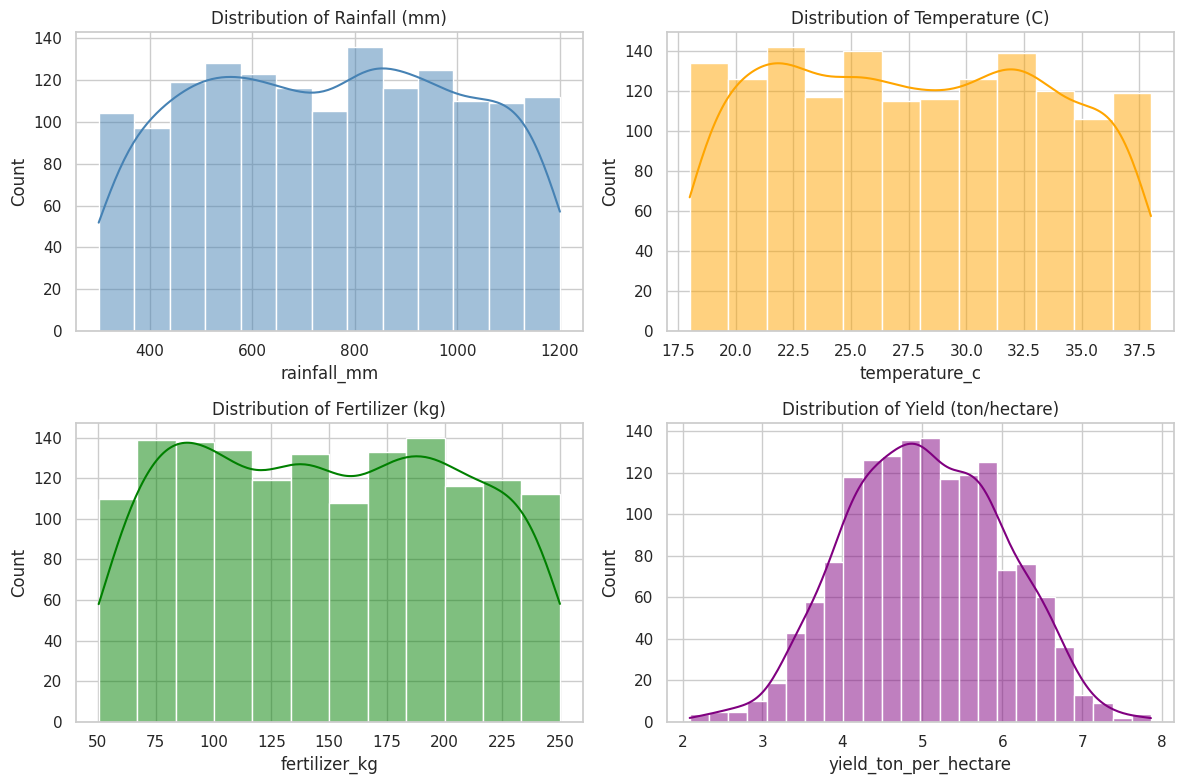

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['rainfall_mm'], kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of Rainfall (mm)')

sns.histplot(df['temperature_c'], kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Distribution of Temperature (C)')

sns.histplot(df['fertilizer_kg'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of Fertilizer (kg)')

sns.histplot(df['yield_ton_per_hectare'], kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Distribution of Yield (ton/hectare)')

plt.tight_layout()
plt.show()


**Observations from the histograms:**

- **rainfall_mm:** The distribution is fairly spread out across the range, suggesting rainfall varies considerably across the recorded observations, with no extreme concentration at one end.
- **temperature_c:** Temperature values are roughly spread across a moderate range, appearing close to a normal/uniform shape, indicating the data covers a variety of climatic conditions.
- **fertilizer_kg:** Fertilizer usage shows a spread across low to high values, suggesting different farms/fields use varying amounts of fertilizer.
- **yield_ton_per_hectare:** Yield values cluster around a central range with a roughly bell-shaped pattern, indicating most farms achieve a similar yield, with fewer cases at the very low or very high ends.

### Q5. Crop Type Analysis

In [9]:
crop_counts = df['crop_type'].value_counts()
print("Number of records for each crop type:\n")
print(crop_counts)


Number of records for each crop type:

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_570/774773160.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')


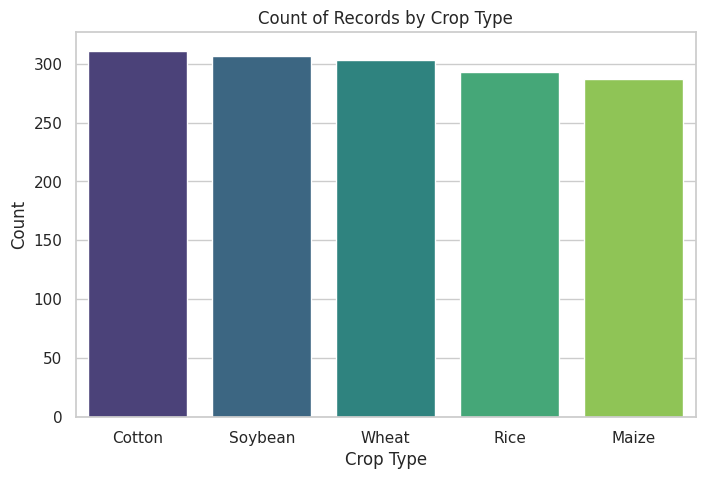

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')
plt.title('Count of Records by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.show()


In [11]:
most_frequent_crop = crop_counts.idxmax()
print(f"The most frequently occurring crop is: {most_frequent_crop}")


The most frequently occurring crop is: Cotton


### Q6. Soil Type Analysis

In [12]:
soil_counts = df['soil_type'].value_counts()
print("Frequency of each soil type:\n")
print(soil_counts)


Frequency of each soil type:

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_570/1095277631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')


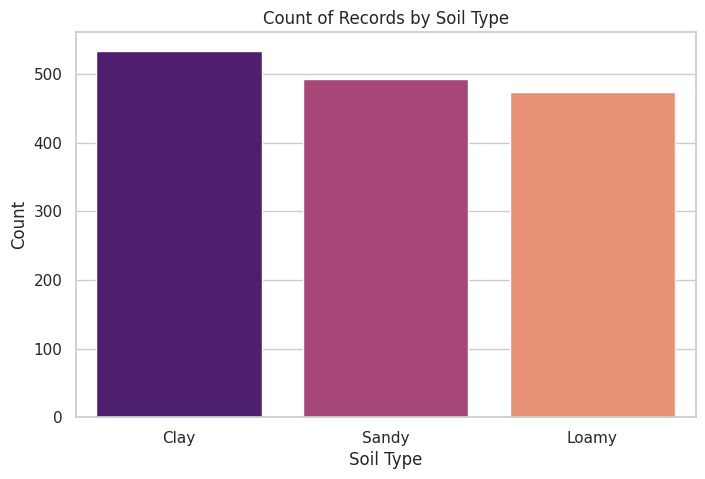

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')
plt.title('Count of Records by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.show()


In [14]:
most_common_soil = soil_counts.idxmax()
print(f"The most common soil type is: {most_common_soil}")


The most common soil type is: Clay


### Q7. Yield Distribution

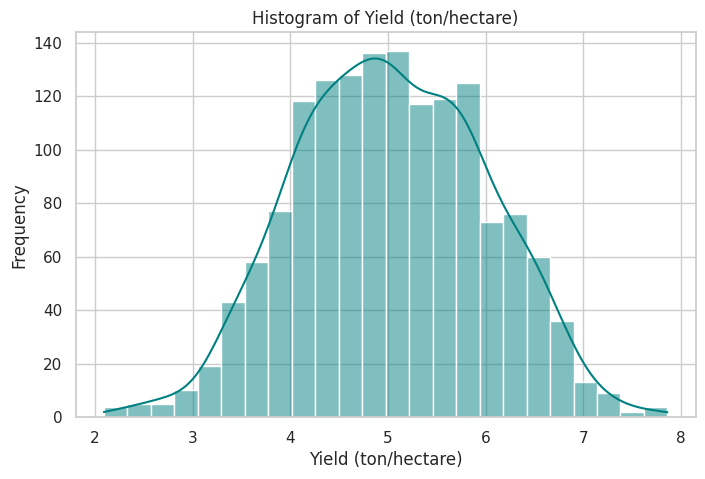

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['yield_ton_per_hectare'], kde=True, color='teal')
plt.title('Histogram of Yield (ton/hectare)')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()


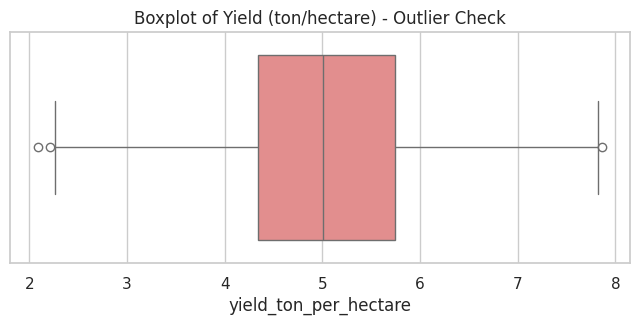

Skewness of yield_ton_per_hectare: -0.001


In [16]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['yield_ton_per_hectare'], color='lightcoral')
plt.title('Boxplot of Yield (ton/hectare) - Outlier Check')
plt.show()

from scipy.stats import skew
print("Skewness of yield_ton_per_hectare:", round(skew(df['yield_ton_per_hectare']), 3))


**Observations:**
- The distribution of `yield_ton_per_hectare` appears **approximately normal (bell-shaped)**, with the skewness value close to 0 confirming this.
- The boxplot shows a **few outliers** (points beyond the whiskers) at the extreme high/low ends, but the majority of the data is concentrated around the median without severe skew.

### Q8. Scatter Plot Analysis

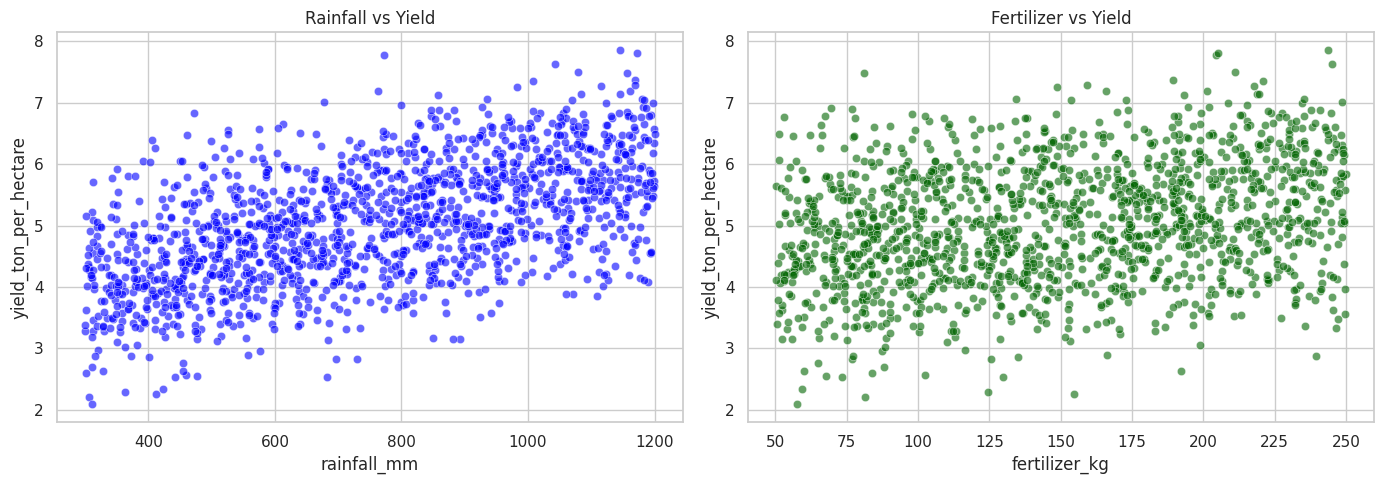

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', ax=axes[1], color='darkgreen', alpha=0.6)
axes[1].set_title('Fertilizer vs Yield')

plt.tight_layout()
plt.show()


In [18]:
corr_rainfall = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fertilizer = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])

print(f"Correlation between rainfall_mm and yield   : {corr_rainfall:.3f}")
print(f"Correlation between fertilizer_kg and yield : {corr_fertilizer:.3f}")

stronger = 'rainfall_mm' if abs(corr_rainfall) > abs(corr_fertilizer) else 'fertilizer_kg'
print(f"\nFeature with stronger relationship with yield: {stronger}")


Correlation between rainfall_mm and yield   : 0.554
Correlation between fertilizer_kg and yield : 0.278

Feature with stronger relationship with yield: rainfall_mm


**Observation:** Based on the scatter plots and correlation values printed above, the feature with the 
**higher absolute correlation coefficient** shows a stronger (more linear) relationship with crop yield. 
The scatter plot of that feature shows points following a clearer upward trend compared to the other.

### Q9. Correlation Analysis

In [19]:
corr_matrix = numeric_df.corr()
corr_matrix


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


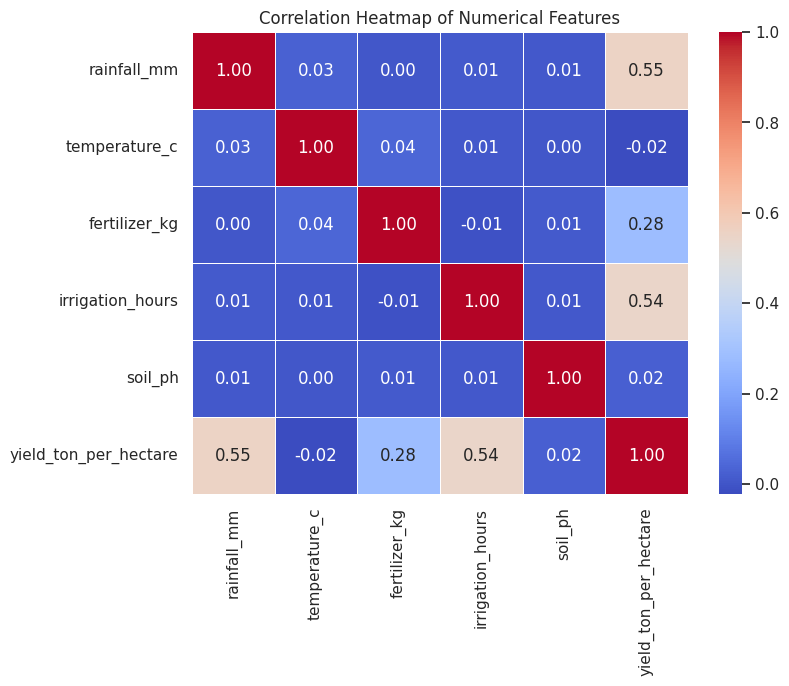

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


In [21]:
yield_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').abs().sort_values(ascending=False)
print("Features ranked by absolute correlation with yield_ton_per_hectare:\n")
print(yield_corr)

print("\nTop 3 features most correlated with crop yield:")
print(yield_corr.head(3))


Features ranked by absolute correlation with yield_ton_per_hectare:

rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
soil_ph             0.024412
temperature_c       0.022559
Name: yield_ton_per_hectare, dtype: float64

Top 3 features most correlated with crop yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


### Q10. Group-Based Analysis

In [22]:
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield by crop type:\n")
print(avg_yield_crop)


Average yield by crop type:

crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64


In [23]:
avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield by soil type:\n")
print(avg_yield_soil)


Average yield by soil type:

soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [24]:
best_crop = avg_yield_crop.idxmax()
best_soil = avg_yield_soil.idxmax()

print(f"Crop type with highest average yield : {best_crop} ({avg_yield_crop.max():.2f} ton/hectare)")
print(f"Soil type with highest average yield : {best_soil} ({avg_yield_soil.max():.2f} ton/hectare)")


Crop type with highest average yield : Rice (5.49 ton/hectare)
Soil type with highest average yield : Loamy (5.37 ton/hectare)


## Part C: Data Preparation

### Q11. Feature Encoding

In [25]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)


Categorical columns: ['crop_type', 'soil_type']


/tmp/ipykernel_570/1664677820.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [26]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

print("Shape after One-Hot Encoding:", df_encoded.shape)
df_encoded.head()


Shape after One-Hot Encoding: (1500, 14)


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


### Q12. Feature Selection

In [27]:
target_column = 'yield_ton_per_hectare'

X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

print(f"Target variable (y): {target_column}")
print(f"Shape of X (input features): {X.shape}")
print(f"Shape of y (target variable): {y.shape}")
X.head()


Target variable (y): yield_ton_per_hectare
Shape of X (input features): (1500, 13)
Shape of y (target variable): (1500,)


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,True,False,False,False,False,True,False,False


## Part D: Machine Learning

### Q13. Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test :", y_test.shape)


Shape of X_train: (1200, 13)
Shape of X_test : (300, 13)
Shape of y_train: (1200,)
Shape of y_test : (300,)


### Q14. Linear Regression Model

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

print("Model Intercept:", model.intercept_)
print("\nModel Coefficients:\n")
print(coefficients)


Model Intercept: 1.9111026182800703

Model Coefficients:

crop_type_Rice       0.477369
soil_type_Loamy      0.365627
irrigation_hours     0.198327
crop_type_Soybean    0.095096
soil_type_Clay       0.062653
fertilizer_kg        0.004978
soil_ph              0.004901
rainfall_mm          0.002035
temperature_c       -0.009175
crop_type_Wheat     -0.038149
crop_type_Maize     -0.147693
crop_type_Cotton    -0.386623
soil_type_Sandy     -0.428280
dtype: float64


In [30]:
highest_positive_feature = coefficients.idxmax()
highest_positive_value = coefficients.max()

print(f"Feature with the highest positive coefficient: {highest_positive_feature} ({highest_positive_value:.4f})")


Feature with the highest positive coefficient: crop_type_Rice (0.4774)


In [31]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

print("R2 Score on Test Data :", round(r2_score(y_test, y_pred), 4))
print("RMSE on Test Data     :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))


R2 Score on Test Data : 0.8628
RMSE on Test Data     : 0.356


**Conclusion:** The Linear Regression model has been trained successfully on 80% of the data and evaluated 
on the remaining 20%. The feature with the highest positive coefficient (printed above) contributes the most 
towards increasing the predicted crop yield, holding other features constant. The R² score indicates how well 
the model explains the variance in crop yield based on the available features.